# PFDA Project: E-Commerce & Consumer Behaviour

## About the File

Source: [Customer Shopping Trends Dataset](https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset)

Why was this chosen? 

I have a strong academic background in marketing, it was my favourite subject in College -- this topic is all about Big Data and data analysis. 

### Part 1: Importing Databases & Loading the Data

In [68]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from geopy.geocoders import Nominatim
from datetime import datetime
from sklearn.linear_model import LinearRegression
import plotly.express as px
import seaborn as sns
import os
import geonamescache as gc

# Confirmation message
print("Libraries loaded successfully!")

Libraries loaded successfully!


### Data Retrieval and Loading 

In [69]:
# Loading the CSV file
# Define terminology for file path
FILENAME = "Ecommerce_Consumer_Behavior_Analysis_Data.csv"
DATADIR = "data/"
FULLPATH = DATADIR + FILENAME

# Read the CSV file into a DataFrame with error handling
if os.path.exists(FULLPATH):
	df = pd.read_csv(FULLPATH, encoding='utf-8')
	print(f"Successfully loaded dataset: {FILENAME}")
	print(f"Dataset shape: {df.shape}")
else:
	print(f"File not found: {FULLPATH}")
	print("Please check the file path and ensure the data directory exists")

# Display the first few rows of the DataFrame
display(df.head())

Successfully loaded dataset: Ecommerce_Consumer_Behavior_Analysis_Data.csv
Dataset shape: (1000, 28)


,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4


In [70]:
# Show the shape of the DataFrame
df.shape

(1000, 28)

In [71]:
# DataFrame information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            1000 non-null   object 
 1   Age                                    1000 non-null   int64  
 2   Gender                                 1000 non-null   object 
 3   Income_Level                           1000 non-null   object 
 4   Marital_Status                         1000 non-null   object 
 5   Education_Level                        1000 non-null   object 
 6   Occupation                             1000 non-null   object 
 7   Location                               1000 non-null   object 
 8   Purchase_Category                      1000 non-null   object 
 9   Purchase_Amount                        1000 non-null   object 
 10  Frequency_of_Purchase                  1000 non-null   int64  
 11  Purch

From the results above, I am aware that there are NaN cells within the DataFrame, especifically in the 'Social Media Influence' and ' Engagement with Ads' Columns.

In [72]:
# Statistical summary of the DataFrame (taking into account only numerical columns)
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,Age,Frequency_of_Purchase,Brand_Loyalty,Product_Rating,Time_Spent_on_Product_Research(hours),Return_Rate,Customer_Satisfaction,Time_to_Decision
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,34.30,6.95,3.03,3.03,1.01,0.95,5.40,7.55
std,9.35,3.15,1.42,1.44,0.79,0.81,2.87,4.04
min,18.00,2.00,1.00,1.00,0.00,0.00,1.00,1.00
25%,26.00,4.00,2.00,2.00,0.00,0.00,3.00,4.00
50%,34.50,7.00,3.00,3.00,1.00,1.00,5.00,8.00
75%,42.00,10.00,4.00,4.00,2.00,2.00,8.00,11.00
max,50.00,12.00,5.00,5.00,2.00,2.00,10.00,14.00


### Part 2: Cleaning the Data

In [73]:
# Double checking for missing values in the dataset
df.isnull().sum()

Customer_ID                                0
Age                                        0
Gender                                     0
Income_Level                               0
Marital_Status                             0
Education_Level                            0
Occupation                                 0
Location                                   0
Purchase_Category                          0
Purchase_Amount                            0
Frequency_of_Purchase                      0
Purchase_Channel                           0
Brand_Loyalty                              0
Product_Rating                             0
Time_Spent_on_Product_Research(hours)      0
Social_Media_Influence                   247
Discount_Sensitivity                       0
Return_Rate                                0
Customer_Satisfaction                      0
Engagement_with_Ads                      256
Device_Used_for_Shopping                   0
Payment_Method                             0
Time_of_Pu

In [74]:
# We need to handle missing values before we get cracking with the analysis
df = df.dropna()
print("Missing values handled. Updated DataFrame shape:", df.shape)

Missing values handled. Updated DataFrame shape: (564, 28)


In [75]:
# Let's check if the data has been normalised
df.isnull().sum()

Customer_ID                              0
Age                                      0
Gender                                   0
Income_Level                             0
Marital_Status                           0
Education_Level                          0
Occupation                               0
Location                                 0
Purchase_Category                        0
Purchase_Amount                          0
Frequency_of_Purchase                    0
Purchase_Channel                         0
Brand_Loyalty                            0
Product_Rating                           0
Time_Spent_on_Product_Research(hours)    0
Social_Media_Influence                   0
Discount_Sensitivity                     0
Return_Rate                              0
Customer_Satisfaction                    0
Engagement_with_Ads                      0
Device_Used_for_Shopping                 0
Payment_Method                           0
Time_of_Purchase                         0
Discount_Us

In [76]:
# Convert 'Time_of_Purchase' to datetime format
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'], format='%m/%d/%Y')

In [77]:
# It seems to have a larteg number of cities. Let's see how many countries we have sold our products.
# Using geonamescache to map cities to countries
gc_instance = gc.GeonamesCache()
countries = gc_instance.get_countries()
print(f"Total countries found: {len(countries)}")

Total countries found: 252


In [78]:
# Where are our customers from?
# Using geonamescache to map cities to countries
gc_instance = gc.GeonamesCache()
city_data = gc_instance.get_cities()
city_to_country = {city['name']: city['countrycode'] for city in city_data.values()}
df['Country'] = df['Location'].map(city_to_country)
print("Unique countries in dataset:", df['Country'].unique())
# Some cities might not be mapped, let's fill those with 'Unknown'
df['Country'] = df['Country'].fillna('Unknown')
print("Unique countries after filling unknowns:", df['Country'].unique())

Unique countries in dataset: ['CN' nan 'US' 'HU' 'NP' 'BR' 'FR' 'BE' 'PT' 'PH' 'RU' 'HN' 'ID' 'CO' 'IT'
 'PL' 'NO' 'JP' 'TN' 'MX' 'BO' 'AR' 'XK' 'MO' 'KR' 'NZ' 'MY' 'TJ' 'CL'
 'EG' 'GH' 'AF' 'ZA' 'TH' 'IR' 'BD' 'MG' 'BF' 'VN' 'MW' 'SS' 'JO' 'EC'
 'CA' 'SE' 'PE' 'SV' 'NG' 'UG' 'KZ' 'BG' 'PS' 'LK' 'RS' 'AL' 'MM' 'LR'
 'AO' 'VE' 'KW' 'ES' 'KG' 'KP' 'DE' 'HK' 'NL' 'CU' 'TZ' 'HT']
Unique countries after filling unknowns: ['CN' 'Unknown' 'US' 'HU' 'NP' 'BR' 'FR' 'BE' 'PT' 'PH' 'RU' 'HN' 'ID'
 'CO' 'IT' 'PL' 'NO' 'JP' 'TN' 'MX' 'BO' 'AR' 'XK' 'MO' 'KR' 'NZ' 'MY'
 'TJ' 'CL' 'EG' 'GH' 'AF' 'ZA' 'TH' 'IR' 'BD' 'MG' 'BF' 'VN' 'MW' 'SS'
 'JO' 'EC' 'CA' 'SE' 'PE' 'SV' 'NG' 'UG' 'KZ' 'BG' 'PS' 'LK' 'RS' 'AL'
 'MM' 'LR' 'AO' 'VE' 'KW' 'ES' 'KG' 'KP' 'DE' 'HK' 'NL' 'CU' 'TZ' 'HT']


In [79]:
# How many unique countries do we have in the dataset?
unique_countries = df['Country'].nunique()
print("Number of unique countries in the dataset:", unique_countries)

Number of unique countries in the dataset: 69


And we'll create group ages, for a cleaners analysis

In [80]:
# First create Age_Group from Age column
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100], labels=['18-25', '26-35', '36-45', '46-55', '55+'])

# And now we'll plot the age group distribution
age_group_counts = df['Age_Group'].value_counts().sort_index()
age_group_counts

Age_Group
18-25    128
26-35    188
36-45    171
46-55     77
55+        0
Name: count, dtype: int64

In [81]:
# Check if df exists and group by Gender to calculate the average purchase amount
if 'df' in locals():
	# Check if Purchase_Amount is already numeric, if not convert it
	if df['Purchase_Amount'].dtype == 'object':
		df['Purchase_Amount'] = df['Purchase_Amount'].str.replace('$', '').astype(float)
	
	result = df.groupby('Gender')['Purchase_Amount'].mean()
	print("Average Purchase Amount by Gender:")
	print(result)
else:
	print("DataFrame 'df' not found. Please run cells 4 and 9 first to load and clean the data.")

Average Purchase Amount by Gender:
Gender
Agender       240.26
Bigender      257.40
Female        292.32
Genderfluid   274.57
Genderqueer   248.56
Male          269.40
Non-binary    266.34
Polygender    319.96
Name: Purchase_Amount, dtype: float64


In [82]:
# Swapping any other gender that is not Female or Male into Other
df['Gender'] = df['Gender'].apply(lambda x: x if x in ['Female', 'Male'] else 'Other') # Standardising gender
print("Unique genders after grouping:", df['Gender'].unique())

Unique genders after grouping: ['Male' 'Female' 'Other']


In [83]:
# Saving cleaned data to a new CSV file  for easy access later
CLEANED_FILENAME = "Consumer_Behavior_Clean.csv"
CLEANED_FULLPATH = DATADIR + CLEANED_FILENAME
df.to_csv(CLEANED_FULLPATH, index=False)

### Part 3: Exploring the data

#### Customer & Conversion Questions

* **Who are my customers? (Demographics, age, gender, location, income, occupation)**

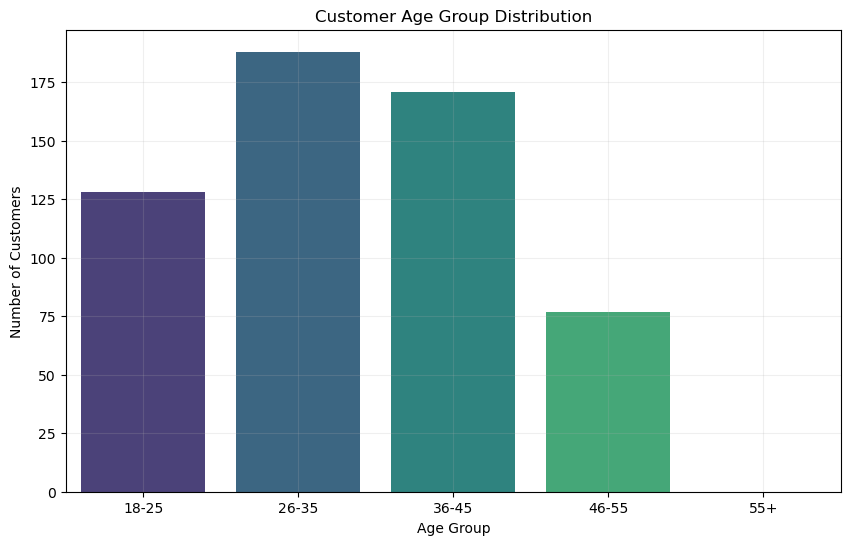

In [84]:
# To vetter view out customer groups, let's plot the data above:
plt.figure(figsize=(10,6))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, palette='viridis', hue=age_group_counts.index, legend=False)
plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.grid(alpha=0.2)
plt.show()

In [85]:
# Purchase amount per age group
# Organise Purchase_Amount from lowert to highest
# Purchase amount per age group  
# Organise Purchase_Amount from lowest to highest
df_sorted = df.sort_values('Purchase_Amount')
fig = px.box(df_sorted, x='Age_Group', y='Purchase_Amount', color='Age_Group', title='Purchase Amount Distribution by Age Group')
fig.update_layout(width=1300, height=800)
fig.show()

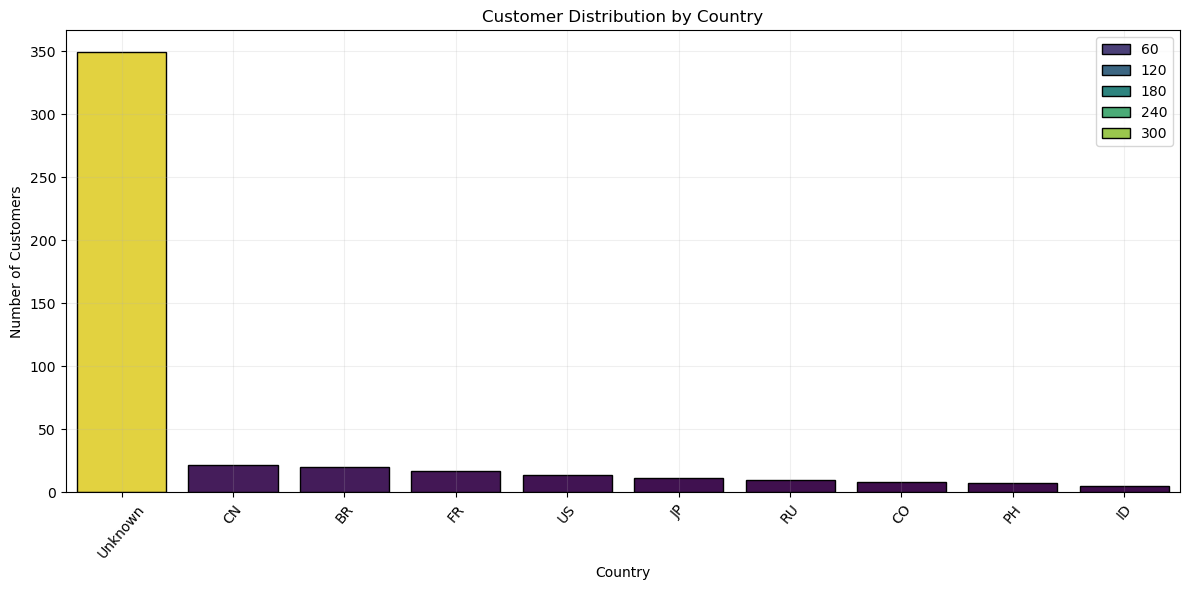

In [127]:
# Plotting the distribution of customers by the top 10 countries
country_counts = df['Country'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette='viridis', edgecolor='black', hue=country_counts.values, dodge=False)
plt.title('Customer Distribution by Country')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=50, fontsize=10)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Average Purchase Amount by Country (Top 10)')

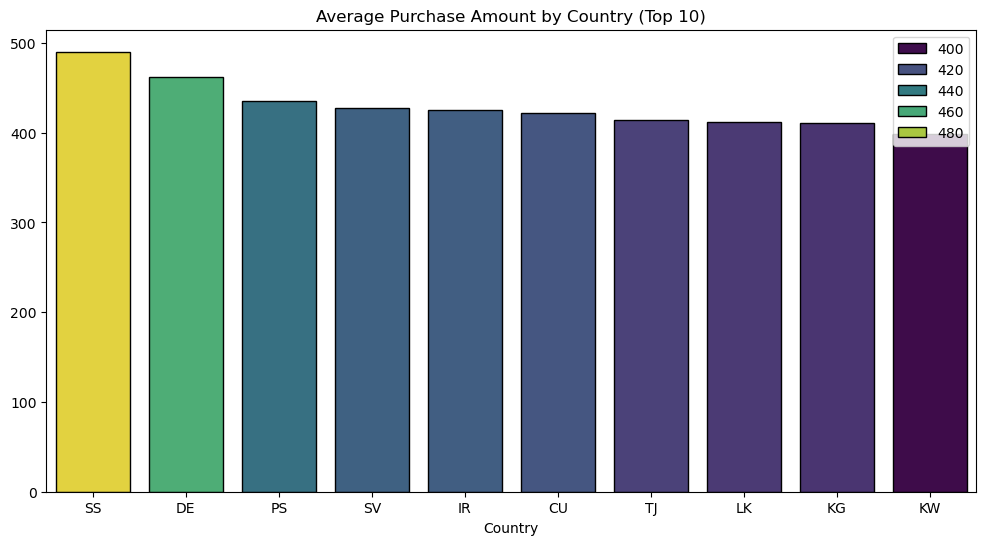

In [128]:
# Average Purchase Amount by Country
avg_purchase_by_country = df.groupby('Country')['Purchase_Amount'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_purchase_by_country.index, y=avg_purchase_by_country.values, palette='viridis', edgecolor='black', hue=avg_purchase_by_country.values, dodge=False)
plt.title('Average Purchase Amount by Country (Top 10)')

In [129]:
# Checking if there is a correlation between age groups and purchase amount
# First ensure Purchase_Amount is numeric
# Check if Purchase_Amount is already numeric, if not convert it
if df['Purchase_Amount'].dtype == 'object':
    df['Purchase_Amount'] = df['Purchase_Amount'].str.replace('$', '').astype(float)

# Create crosstab with age groups and purchase amount bins
pd.crosstab(pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65, 75, 85]),
            pd.cut(df['Purchase_Amount'], bins=[0, 50, 100, 150, 200, 250, 300, 500])).apply(lambda r: r/r.sum(), axis=1)

Purchase_Amount,"(50, 100]","(100, 150]","(150, 200]","(200, 250]","(250, 300]","(300, 500]"
Age,,,,,,
"(18, 25]",0.07,0.07,0.12,0.14,0.07,0.53
"(25, 35]",0.12,0.11,0.11,0.13,0.09,0.45
"(35, 45]",0.11,0.10,0.11,0.11,0.09,0.49
"(45, 55]",0.21,0.13,0.10,0.06,0.12,0.38


* **What are they doing? (Behavioral)**

In [90]:
# Checking 'Gender' and 'Purchase Channel' relationship 
pd.crosstab(df['Gender'], df['Purchase_Channel'], normalize=True) * 100     # Show percentages

Purchase_Channel,In-Store,Mixed,Online
Gender,,,
Female,14.18,14.72,15.96
Male,15.60,17.02,13.30
Other,2.66,2.84,3.72


* How do they browse and buy? (Frequent browsers, cart abandoners, first-time vs. repeat buyers).

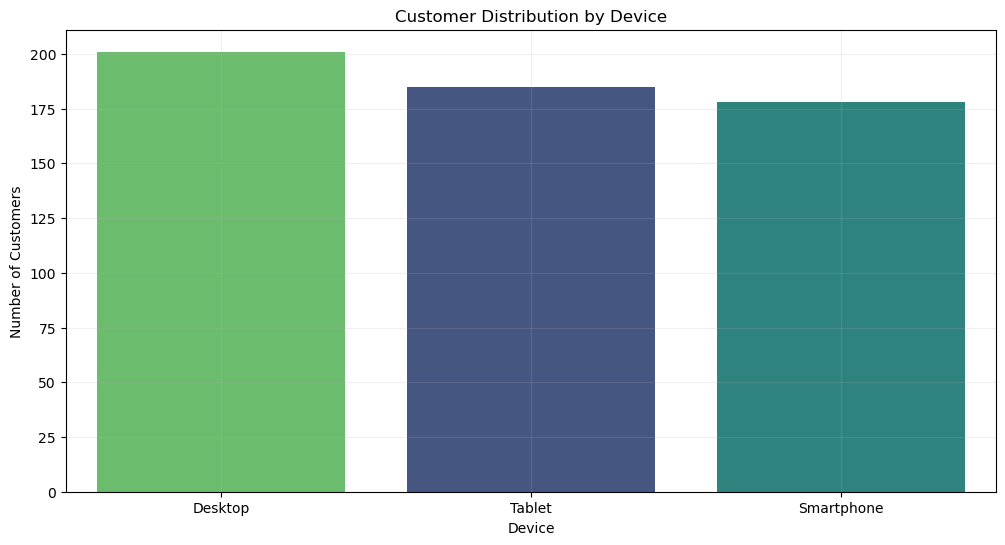

In [91]:
# What device do they access the platform from?
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Device_Used_for_Shopping', order=df['Device_Used_for_Shopping'].value_counts().index, palette='viridis', hue='Device_Used_for_Shopping')
plt.title('Customer Distribution by Device')
plt.xlabel('Device')
plt.ylabel('Number of Customers')
plt.grid(alpha=0.2)
plt.show()

In [ ]:
# Creating boxplots of Purchase Amount by Purchase Intent
fig = px.box(df, x='Purchase_Intent', y='Purchase_Amount')
fig.update_layout(width=1200, height=600)
fig.show()

In [130]:
# Let's create a correlation heatmap to visualise relationships between variables
# Purchase_Amount is already in numeric format from previous processing

corr = df[['Age', 'Purchase_Amount', 'Frequency_of_Purchase', 'Time_Spent_on_Product_Research(hours)', 'Time_to_Decision']].corr()

# First we'll make sure to show only two decimal places
corr = corr.round(2)

# And we'll plot it and style it
px.imshow(corr, text_auto=True, title='Correlation Heatmap',
          color_continuous_scale='Viridis',
          labels={'color': 'Correlation Coefficient'}).update_layout(width=800, height=600)


In [131]:
# How many, in percentage terms, are members of our loyalty program?
loyalty_counts = df['Customer_Loyalty_Program_Member'].value_counts(normalize=True) * 100
loyalty_counts

Customer_Loyalty_Program_Member
False   50.53
True    49.47
Name: proportion, dtype: float64

* What convinced them to buy? (Valued features, trust signals). 

In [95]:
# Checking if there is a correlation between age groups and purchase amount
pd.crosstab(pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65, 75, 85]),
            pd.cut(df['Purchase_Amount'], bins=[0, 50, 100, 150, 200, 250, 300])).apply(lambda r: r/r.sum(), axis=1)

Purchase_Amount,"(50, 100]","(100, 150]","(150, 200]","(200, 250]","(250, 300]"
Age,,,,,
"(18, 25]",0.14,0.14,0.27,0.30,0.14
"(25, 35]",0.21,0.19,0.19,0.24,0.16
"(35, 45]",0.21,0.20,0.21,0.22,0.17
"(45, 55]",0.33,0.21,0.17,0.10,0.19


In [96]:
# How many customers, in percentage, are repeat buyers?
# Create repeat buyer indicator based on frequency of purchase
df['Repeat_Buyer'] = df['Frequency_of_Purchase'] > 1
repeat_buyer_counts = df['Repeat_Buyer'].value_counts(normalize=True) * 100
repeat_buyer_counts

Repeat_Buyer
True   100.00
Name: proportion, dtype: float64

In [97]:
# How many customers are highly satisfied (rating of 4 or more)?
highly_satisfied_counts = (df['Customer_Satisfaction'] >= 4).value_counts(normalize=True) * 100
highly_satisfied_counts

Customer_Satisfaction
True    67.73
False   32.27
Name: proportion, dtype: float64

* What are their values, interests, or lifestyle? (Personality traits, tech adoption).
* How did they first hear about us? (Marketing channel effectiveness). **(Discount and advertising)**

**Customer Segmentation**

In [132]:
# We need to ensure the Purchase_Amount column is in float format
print(f"Purchase_Amount data type: {df['Purchase_Amount'].dtype}")
print(f"Sample values: {df['Purchase_Amount'].head()}")

Purchase_Amount data type: float64
Sample values: 1    222.22
2    426.22
6    486.40
8    201.96
10   389.70
Name: Purchase_Amount, dtype: float64


*  **Where are they coming from? (Channel & Journey) and which marketing channel is performing the best? Social or email or search etc. Performance is usually a rate of some kind - conversion rate or ROI.**

In [133]:
# Now we'll analyse device usage and social media influence
if 'Social_Media_Influence' in df.columns:
	device_social_media = df.groupby('Device_Used_for_Shopping')['Social_Media_Influence'].value_counts(normalize=True).unstack().fillna(0) * 100
	print("\nDevice usage vs Social Media Influence:")
	print(device_social_media)
else:
	print("\nNo social media related column found. Showing device distribution instead:")
	device_distribution = df['Device_Used_for_Shopping'].value_counts()
	print(device_distribution)


Device usage vs Social Media Influence:
Social_Media_Influence    High   Low  Medium
Device_Used_for_Shopping                    
Desktop                  34.33 39.30   26.37
Smartphone               34.27 32.02   33.71
Tablet                   38.38 28.11   33.51


### Exploratory Analysis

### Marketing & Sales Questions

•	Which marketing channels yield the highest ROI/LTV? (Social, email, search, etc.)

•	What's the conversion rate by device, source, or time of day? (Segmentation)

In [134]:
# What period of day and day of the week do most purchases happen?
# Ensure Time_of_Purchase is in datetime format
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'], format='%m/%d/%Y')
df['Day_of_Week'] = df['Time_of_Purchase'].dt.day_name()
purchase_period = df.groupby('Day_of_Week')['Time_of_Purchase'].agg(['count', 'min', 'max'])
purchase_period = purchase_period.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
purchase_period

,count,min,max
Day_of_Week,,,
Monday,84,2024-01-08,2024-12-30
Tuesday,99,2024-01-02,2024-12-24
Wednesday,72,2024-01-10,2024-12-25
Thursday,80,2024-01-04,2024-12-26
Friday,73,2024-01-05,2024-12-27
Saturday,75,2024-01-06,2024-12-28
Sunday,81,2024-01-07,2024-12-29


### Operational & Financial Questions

•	What's our cost per acquisition (CPA) and cost per transaction?

•	what is the best user experience? Usually measured in how quickly or how often the user completes their task (usually the task is making a purchase). Look at conversion rate, time on site, time to purchase, and also A/B (hypothesis) tests are great for analysis.

•   Which customers generate more value? How can we attract more of them? How can we convert other customers to spend more?

•   Average order value (AOV) - Use AOV to track the average amount of money customers spend on each purchase, whether it’s their first order or they’re a returning customer. Combine this with the average number of purchases by each registered customer, and you will be able to get another highly important KPI – Customer Lifetime Value (CLV).

•   Total revenue and Revenue by channel - Different customers approach online shopping in different ways. Tracking revenue breakdown by device, advertising platform, customer location, or any other dimension will allow you to see how your customers are buying your products, and fine-tune your campaigns to improve sales.


In [135]:
# Counting purchases by category
df['Purchase_Category'].value_counts()

Purchase_Category
Furniture                    30
Electronics                  30
Baby Products                28
Health Supplements           28
Packages)                    26
Books                        26
Food & Beverages             24
Arts & Crafts                24
Gardening & Outdoors         24
Jewelry & Accessories        24
Hotels                       24
Home Appliances              24
Groceries                    23
Software & Apps              23
Luxury Goods                 23
Health Care                  23
Toys & Games                 22
Mobile Accessories           22
Animal Feed                  21
Sports & Outdoors            21
Travel & Leisure (Flights    19
Office Supplies              19
Clothing                     18
Beauty & Personal Care       18
Name: count, dtype: int64

In [104]:
# Converting 'Time_of_Purchase' to datetime format
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'], format='%m/%d/%Y')
df['Time_of_Purchase'].head()

1    2024-04-16
2    2024-03-15
6    2024-03-15
8    2024-06-10
10   2024-07-02
Name: Time_of_Purchase, dtype: datetime64[ns]

In [105]:
# Convert Time_of_Purchase to datetime format first, then extract month
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'], format='%m/%d/%Y')
df['Month'] = df['Time_of_Purchase'].dt.month

# Count of purchases by month
df['Month'].value_counts().sort_index()

Month
1     39
2     36
3     56
4     61
5     39
6     58
7     49
8     57
9     51
10    44
11    39
12    35
Name: count, dtype: int64

In [106]:
# Calculating total purchases per month
monthly_totals = df.groupby('Month')['Purchase_Amount'].sum().to_frame()
monthly_totals

,Purchase_Amount
Month,
1,10153.53
2,11076.18
3,17516.80
4,16481.70
5,9791.50
6,17583.94
7,12500.27
8,16195.01
9,14675.68


In [107]:
# Now, We'll calculate the cost per transaction over time
df['Cost_per_Transaction'] = df['Purchase_Amount'] / df['Frequency_of_Purchase']
df[['Purchase_Amount', 'Frequency_of_Purchase', 'Cost_per_Transaction']].head()

,Purchase_Amount,Frequency_of_Purchase,Cost_per_Transaction
1,222.22,11,20.20
2,426.22,2,213.11
6,486.40,12,40.53
8,201.96,8,25.25
10,389.70,12,32.48


In [108]:
# The highest cost per transaction by month
highest_cost_per_transaction = df.groupby('Month')['Cost_per_Transaction'].max().to_frame()
highest_cost_per_transaction

,Cost_per_Transaction
Month,
1,248.90
2,246.37
3,248.88
4,205.91
5,249.16
6,248.06
7,231.48
8,169.81
9,168.48


In [136]:
# Gender and Age Group vs. Purchase Category
purchase_patterns = df.groupby(['Gender', 'Age_Group'])['Purchase_Category'].value_counts(normalize=True).unstack().fillna(0) * 100
purchase_patterns

C:\Users\35387\AppData\Local\Temp\ipykernel_3348\4082655630.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Purchase_Category  Animal Feed  Arts & Crafts  Baby Products  \
Gender Age_Group                                               
Female 18-25              0.00           0.00           5.08   
       26-35              5.68           5.68           9.09   
       36-45              2.47           8.64           2.47   
       46-55              4.00           4.00           4.00   
       55+                0.00           0.00           0.00   
Male   18-25              2.00           0.00           2.00   
       26-35              7.69           3.30           3.30   
       36-45              4.11           2.74           6.85   
       46-55              2.22           6.67           6.67   
       55+                0.00           0.00           0.00   
Other  18-25              0.00           5.26           5.26   
       26-35             11.11           0.00           0.00   
       36-45              0.00           5.88           5.88   
       46-55              0.00          14.29           0.00   
       55+                0.00           0.00           0.00   

Purchase_Category  Beauty & Personal Care  Books  Clothing  Electronics  \
Gender Age_Group                                                          
Female 18-25                         3.39   3.39      0.00         3.39   
       26-35                         1.14   3.41      4.55         5.68   
       36-45                         2.47   6.17      3.70         8.64   
       46-55                         8.00   0.00      4.00         8.00   
       55+                           0.00   0.00      0.00         0.00   
Male   18-25                         4.00   8.00      0.00         6.00   
       26-35                         3.30   4.40      4.40         3.30   
       36-45                         1.37   6.85      2.74         5.48   
       46-55                         8.89   6.67      2.22         2.22   
       55+                           0.00   0.00      0.00         0.00   
Other  18-25                         0.00   0.00      0.00         0.00   
       26-35                         0.00   0.00     22.22        11.11   
       36-45                         5.88   0.00      5.88         5.88   
       46-55                         0.00   0.00      0.00        14.29   
       55+                           0.00   0.00      0.00         0.00   

Purchase_Category  Food & Beverages  Furniture  Gardening & Outdoors  ...  \
Gender Age_Group                                                      ...   
Female 18-25                   5.08       6.78                  3.39  ...   
       26-35                   4.55       2.27                  4.55  ...   
       36-45                   3.70       4.94                  2.47  ...   
       46-55                   8.00       8.00                  4.00  ...   
       55+                     0.00       0.00                  0.00  ...   
Male   18-25                   4.00       8.00                  8.00  ...   
       26-35                   4.40       1.10                  6.59  ...   
       36-45                   2.74      10.96                  1.37  ...   
       46-55                   4.44       4.44                  6.67  ...   
       55+                     0.00       0.00                  0.00  ...   
Other  18-25                   5.26       5.26                  0.00  ...   
       26-35                   0.00       0.00                 11.11  ...   
       36-45                   5.88      11.76                  0.00  ...   
       46-55                   0.00       0.00                  0.00  ...   
       55+                     0.00       0.00                  0.00  ...   

Purchase_Category  Hotels  Jewelry & Accessories  Luxury Goods  \
Gender Age_Group                                                 
Female 18-25         6.78                   5.08          8.47   
       26-35         4.55                   6.82          3.41   
       36-45         3.70                   7.41          2.4

In [110]:
# What is the top 2 catergory per gender and age group?
top_categories = purchase_patterns.apply(lambda x: x.nlargest(2).index.tolist(), axis=1)
top_categories

Gender  Age_Group
Female  18-25                  [Luxury Goods, Mobile Accessories]
        26-35                          [Baby Products, Packages)]
        36-45                        [Arts & Crafts, Electronics]
        46-55              [Toys & Games, Beauty & Personal Care]
        55+                          [Animal Feed, Arts & Crafts]
Male    18-25                          [Sports & Outdoors, Books]
        26-35                   [Health Supplements, Animal Feed]
        36-45                          [Furniture, Baby Products]
        46-55        [Beauty & Personal Care, Health Supplements]
        55+                          [Animal Feed, Arts & Crafts]
Other   18-25                        [Packages), Software & Apps]
        26-35                             [Clothing, Animal Feed]
        36-45                     [Furniture, Health Supplements]
        46-55                          [Packages), Arts & Crafts]
        55+                          [Animal Feed, Arts & 

C:\Users\35387\AppData\Local\Temp\ipykernel_3348\1082945862.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




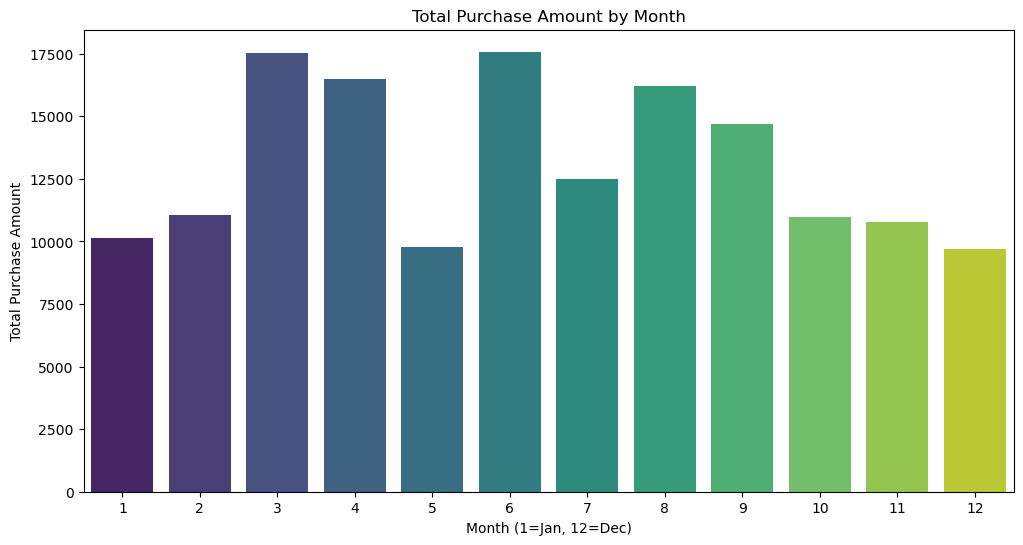

In [111]:
# Visualize the average purchase amount
plt.figure(figsize=(12,6))
sns.barplot(x=monthly_totals.index, y=monthly_totals['Purchase_Amount'], palette='viridis')
plt.title('Total Purchase Amount by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Total Purchase Amount')
plt.show()

•	How effective are our promotions/discounts? 

In [112]:
# How does each age group perform regarding advertisement engagement and purchase amounts?
age_group_performance = df.groupby('Age_Group', observed=False).agg({
	'Engagement_with_Ads': lambda x: x.value_counts().index[0] if len(x.value_counts()) > 0 else 'No Data', 
	'Purchase_Amount': 'mean'
}) 
age_group_performance

,Engagement_with_Ads,Purchase_Amount
Age_Group,,
18-25,High,293.31
26-35,Medium,280.03
36-45,High,282.09
46-55,High,246.83
55+,No Data,NaN


### Advanced Analysis

In [113]:
# Purchasing Trends Over Time - Monthly Purchase Trends
monthly_totals = df.groupby('Month')['Purchase_Amount'].sum().to_frame()
px.line(monthly_totals, x=monthly_totals.index, y='Purchase_Amount', title='Monthly Purchase Trends')

In [114]:
# Projected growth in purchase amount over the next 12 months
# Using a simple linear growth model based on past data
last_month = monthly_totals.index.max()
growth_rate = monthly_totals['Purchase_Amount'].pct_change().mean()

projections = {}
for i in range(1, 13):
    next_month = last_month + i
    projected_amount = monthly_totals['Purchase_Amount'].iloc[-1] * ((1 + growth_rate) ** i)
    projections[next_month] = round(projected_amount, 2) # Only show 2 decimal places
projections

{13: 10167.48,
 14: 10670.67,
 15: 11198.75,
 16: 11752.98,
 17: 12334.63,
 18: 12945.07,
 19: 13585.72,
 20: 14258.08,
 21: 14963.71,
 22: 15704.26,
 23: 16481.46,
 24: 17297.12}

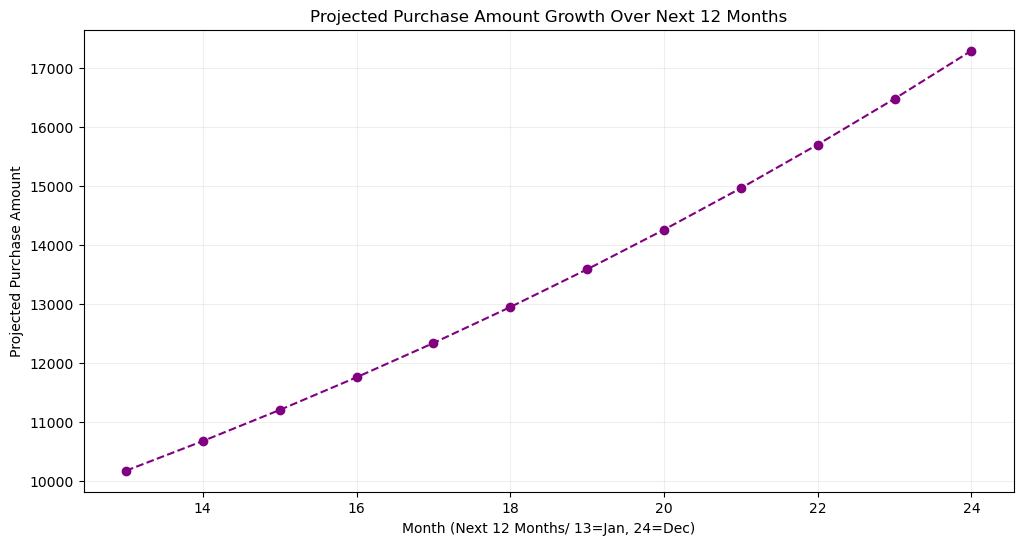

In [115]:
# Now we plot the projected growth
plt.figure(figsize=(12,6))
plt.plot(list(projections.keys()), list(projections.values()), marker='o', linestyle='--', color='purple')
plt.title('Projected Purchase Amount Growth Over Next 12 Months')
plt.xlabel('Month (Next 12 Months/ 13=Jan, 24=Dec)')
plt.ylabel('Projected Purchase Amount')
plt.grid(alpha=0.2)
plt.show()

In [116]:
# Checking if there are outliers in the predictions
# Define the feature matrix first
X = df[['Age', 'Frequency_of_Purchase', 'Time_Spent_on_Product_Research(hours)', 'Time_to_Decision']]

# Generate predictions using the model
# First, ensure the model exists; if not create it
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, df['Purchase_Amount'])

# Generate predictions for the current dataset
projections = model.predict(X)

# Create boxplot of actual predictions (not projections)
fig = px.box(y=projections, title='Boxplot of Predicted Purchase Amounts')
fig.update_layout(width=1200, height=600)
fig.show()


In [117]:
# Scatter plot of actual vs. predicted Purchase Amount
fig = px.scatter(x=df['Purchase_Amount'], y=projections, 
                 labels={'x': 'Actual Purchase Amount', 'y': 'Predicted Purchase Amount'},
                 title='Actual vs. Predicted Purchase Amount')
# Adding a regression line for reference
fig.add_shape(type='line',
              x0=df['Purchase_Amount'].min(), y0=df['Purchase_Amount'].min(),
              x1=df['Purchase_Amount'].max(), y1=df['Purchase_Amount'].max(),
              line=dict(color='Red', dash='dash'))

fig.update_layout(width=1200, height=600)

In [118]:
##### REVIEW THIS #####
# Who has had the best user experience? Based in Customer Satisfaction ratings, loyalty program membership, and time for decision making.
# Create a composite score for user experience
df['User_Experience_Score'] = (df['Customer_Satisfaction'] * 0.5) + (df['Customer_Loyalty_Program_Member'].map({True: 1, False: 0}) * 0.3) + ((1 / (df['Time_to_Decision'] + 1)) * 0.2)
best_experience = df[['Customer_ID', 'User_Experience_Score']].sort_values(by='User_Experience_Score', ascending=False).head(10)
best_experience 

,Customer_ID,User_Experience_Score
258,41-854-0707,5.40
355,72-336-1992,5.40
631,29-067-4901,5.37
653,35-879-0014,5.37
550,06-647-3248,5.33
863,37-100-8709,5.33
405,28-676-0614,5.33
697,44-938-7475,5.33
343,33-467-2534,5.33
962,97-715-3606,5.33


In [119]:
# Income Level vs. Purchase Behavior, grouped by gender
income_stats = df.groupby(['Income_Level', 'Gender'])[['Purchase_Amount', 'Frequency_of_Purchase', 'Time_to_Decision']].mean()
income_stats

Purchase_Amount  Frequency_of_Purchase  Time_to_Decision
Income_Level Gender                                                          
High         Female           292.04                   6.90              7.70
             Male             261.51                   7.05              7.82
             Other            279.44                   7.94              8.03
Middle       Female           292.63                   7.28              7.03
             Male             277.35                   6.91              7.74
             Other            235.75                   7.68              5.21

In [120]:
# Calculating the cost per transaction, per payment method
# Group by payment method and calculate cost per transaction metrics
payment_method_stats = df.groupby('Payment_Method').agg({
    'Purchase_Amount': ['mean', 'sum', 'count'],
    'Cost_per_Transaction': 'mean'
}).round(2)

# Flatten column names for better readability
payment_method_stats.columns = ['Avg_Purchase_Amount', 'Total_Revenue', 'Transaction_Count', 'Avg_Cost_per_Transaction']
payment_method_stats

,Avg_Purchase_Amount,Total_Revenue,Transaction_Count,Avg_Cost_per_Transaction
Payment_Method,,,,
Cash,264.89,25429.68,96,48.52
Credit Card,279.77,34970.88,125,53.31
Debit Card,285.33,29389.23,103,49.38
Other,283.61,34317.04,121,51.27
PayPal,280.05,33325.83,119,57.37


In [121]:
# How do most customers pay?
payment_method_counts = df['Payment_Method'].value_counts()
payment_method_counts

Payment_Method
Credit Card    125
Other          121
PayPal         119
Debit Card     103
Cash            96
Name: count, dtype: int64

In [122]:
# who are our best customers? Or customers with highest total purchase amount
# Define best customers based on total purchase amount
best_customers = df.groupby('Customer_ID').agg({'Purchase_Amount': ['sum', 'count']})

# Sort by total purchase amount to get the best customers
best_customers_sorted = best_customers.sort_values(('Purchase_Amount', 'sum'), ascending=False).head(20)
best_customers_sorted

# And show me the top 20 best customers and if they are using discount, if they are a loyal custmer and their purchase intent
# Get the top 10 customer IDs
top_10_customer_ids = best_customers_sorted.index.tolist()

# Get detailed information for these top customers
top_customers_details = df[df['Customer_ID'].isin(top_10_customer_ids)][['Customer_ID', 'Purchase_Amount', 'Discount_Used', 'Customer_Loyalty_Program_Member', 'Purchase_Intent']].set_index('Customer_ID')
# Sort by purchase amount to match the order
top_customers_details = top_customers_details.loc[top_10_customer_ids]
top_customers_details

,Purchase_Amount,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent
Customer_ID,,,,
60-470-3563,498.33,True,True,Wants-based
15-663-7994,497.80,True,False,Wants-based
86-257-9581,497.76,True,True,Wants-based
72-830-1211,496.11,True,False,Impulsive
69-394-1424,494.97,False,False,Planned
59-261-4453,494.81,True,True,Need-based
82-671-7236,494.34,False,False,Wants-based
92-142-4328,492.83,True,False,Need-based
51-302-9537,492.74,True,False,Need-based


In [123]:
# Out of our 50 best customers, in percentage, how many are members of our loyalty program?
# Get the top 50 customer IDs
top_50_customer_ids = best_customers.sort_values(('Purchase_Amount', 'sum'), ascending=False).head(50).index.tolist()
loyalty_membership = df[df['Customer_ID'].isin(top_50_customer_ids)].groupby('Customer_Loyalty_Program_Member')['Customer_ID'].nunique()
loyalty_percentage = (loyalty_membership / loyalty_membership.sum()) * 100
loyalty_percentage

Customer_Loyalty_Program_Member
False   60.00
True    40.00
Name: Customer_ID, dtype: float64

In [124]:
# # Out of our 50 best customers, in percentage, what are their purchacse intents?
purchase_intent_counts = df[df['Customer_ID'].isin(top_50_customer_ids)].groupby('Purchase_Intent')['Customer_ID'].nunique()
purchase_intent_percentage = (purchase_intent_counts / purchase_intent_counts.sum()) * 100
purchase_intent_percentage

Purchase_Intent
Impulsive     10.00
Need-based    26.00
Planned       28.00
Wants-based   36.00
Name: Customer_ID, dtype: float64

In [125]:
# Within each age group, what is the average time to decision and purchase intent?
age_group_decision_intent = df.groupby('Age_Group').agg({
    'Time_to_Decision': 'mean',
    'Purchase_Intent': lambda x: x.value_counts(normalize=True).idxmax() if len(x) > 0 else 'No Data'  # Most common purchase intent
}).round(2)
age_group_decision_intent



C:\Users\35387\AppData\Local\Temp\ipykernel_3348\2911751301.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Time_to_Decision,Purchase_Intent
Age_Group,,
18-25,7.41,Need-based
26-35,7.21,Wants-based
36-45,7.78,Need-based
46-55,7.95,Wants-based
55+,NaN,No Data


In [126]:
# In percentages, which gender is more likely to use discounts when making purchases?
discount_usage = df.groupby('Gender')['Discount_Used'].mean() * 100
discount_usage

Gender
Female   52.96
Male     51.35
Other    57.69
Name: Discount_Used, dtype: float64

### Part 5: Conclusion